Saving FastFoodNutritionMenuV2.csv to FastFoodNutritionMenuV2 (1).csv
CSV Uploaded Successfully!

      Company                           Item  Calories Calories from\nFat  \
0  McDonald’s                      Hamburger     250.0                 80   
1  McDonald’s                   Cheeseburger     300.0                110   
2  McDonald’s            Double Cheeseburger     440.0                210   
3  McDonald’s                       McDouble     390.0                170   
4  McDonald’s   Quarter Pounder® with Cheese     510.0                230   

  Total Fat\n(g) Saturated Fat\n(g) Trans Fat\n(g) Cholesterol\n(mg)  \
0              9                3.5            0.5                25   
1             12                  6            0.5                40   
2             23                 11            1.5                80   
3             19                  8              1                65   
4             26                 12            1.5                90   

  Sodi

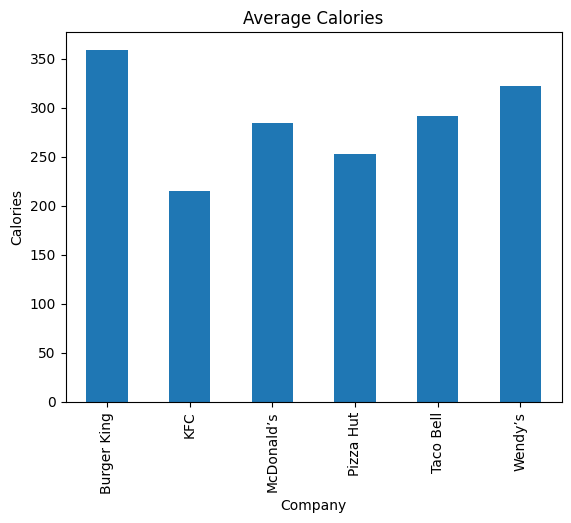


Correlation Matrix:
          Calories
Calories       1.0


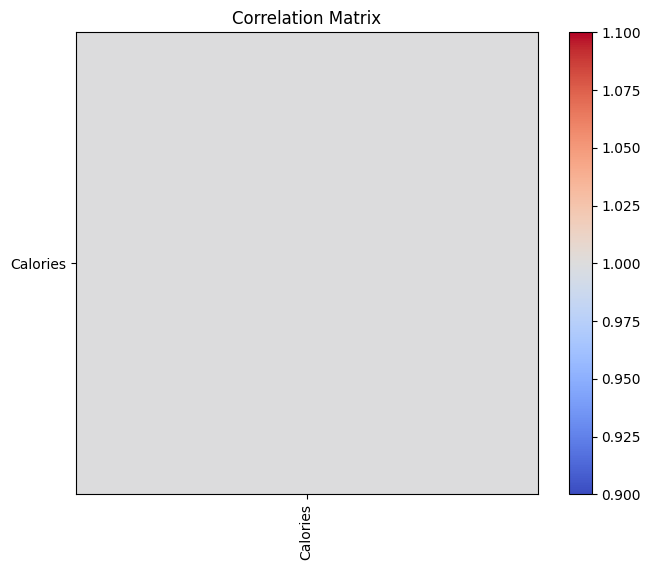

In [ ]:
# ===========================================
# Step 1: Import Libraries
# ===========================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ===========================================
# Step 2: Upload CSV File
# ===========================================

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("CSV Uploaded Successfully!\n")

# ===========================================
# Step 3: Data Inspection and Type Conversion
# ===========================================

# Convert 'Calories' column to numeric, coercing errors to NaN
if 'Calories' in df.columns:
    df['Calories'] = pd.to_numeric(df['Calories'], errors='coerce')

# Drop rows where 'Calories' became NaN after conversion
df.dropna(subset=['Calories'], inplace=True)

print(df.head())

print("\nShape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nSummary:")
print(df.describe())

# ===========================================
# Step 4: Filter Data
# ===========================================

if 'Calories' in df.columns:

    high_cal = df[df['Calories'] > df['Calories'].mean()]

    print("\nItems Above Average Calories:")
    print(high_cal.head())

# ===========================================
# Step 5: Sort Data
# ===========================================

if 'Calories' in df.columns:

    sorted_df = df.sort_values(by='Calories', ascending=False)

    print("\nTop High Calorie Foods:")
    print(sorted_df.head())

# ===========================================
# Step 6: Statistical Analysis
# ===========================================

if 'Calories' in df.columns:

    print("\nMean =", df['Calories'].mean())
    print("Median =", df['Calories'].median())
    print("Mode =")
    print(df['Calories'].mode())
    print("Standard Deviation =", df['Calories'].std())

# ===========================================
# Step 7: Grouping
# ===========================================

cat_cols = df.select_dtypes(include='object').columns

if len(cat_cols) > 0:

    first_cat = cat_cols[0]

    group = df.groupby(first_cat)['Calories'].mean()

    print("\nAverage Calories by", first_cat)
    print(group)

    group.plot(kind='bar')

    plt.title("Average Calories")
    plt.ylabel("Calories")
    plt.show()

# ===========================================
# Step 8: Correlation
# ===========================================

corr = df.corr(numeric_only=True)

print("\nCorrelation Matrix:")
print(corr)

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()